# 11 · Predictive Modeling — Ride Demand Forecasting

**NEW notebook — this was entirely missing from the original implementation and is an explicit project requirement.**

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import load_and_clean_data


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Build the cleaned/feature-engineered dataframe directly from the raw file,
# using the shared pipeline in src/preprocessing.py (keeps this notebook runnable
# standalone, with no dependency on a pre-built intermediate file).
uber_df = load_and_clean_data('../data/Uber_Drive_Raw.csv')
uber_df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,waiting time,Avg CTAT,...,Date_only,Year,Month,Month_Name,Day,Day_of_week,Is_Weekend,Hour,Day-Night,Peak_Hour
0,2025-01-12,1900-01-01 15:44:00,UBR100294,Cancelled by Driver,CUST1016,UberXL,Toronto,Melbourne,9.1,4.9,...,2025-01-12,2025,1,January,12,Sunday,Yes,15,Afternoon,Non-Peak Hour
1,2025-03-12,1900-01-01 05:17:00,UBR100453,Completed,CUST1040,Uber Black,Los Angeles,Madrid,11.3,4.9,...,2025-03-12,2025,3,March,12,Wednesday,No,5,Morning,Non-Peak Hour
2,2025-01-13,1900-01-01 11:35:00,UBR100638,Completed,CUST1004,Uber Comfort,Melbourne,Dubai,3.7,18.2,...,2025-01-13,2025,1,January,13,Monday,No,11,Morning,Non-Peak Hour
3,2025-05-22,1900-01-01 08:00:00,UBR100139,Cancelled by Driver,CUST1150,UberXL,Birmingham,Manchester,6.8,11.4,...,2025-05-22,2025,5,May,22,Thursday,No,8,Morning,Peak Hour
4,2025-01-20,1900-01-01 11:30:00,UBR100804,Completed,CUST1077,Uber Green,Paris,Dubai,10.2,24.3,...,2025-01-20,2025,1,January,20,Monday,No,11,Morning,Non-Peak Hour


In [4]:
daily_df = uber_df.groupby('Date_only').agg(ride_count=('Booking ID','count'), avg_booking_value=('Booking Value','mean')).reset_index()
daily_df['Date_only'] = pd.to_datetime(daily_df['Date_only'])  # groupby key comes back as plain date objects
daily_df['DayOfWeekNum'] = daily_df['Date_only'].dt.dayofweek
daily_df['Month'] = daily_df['Date_only'].dt.month
daily_df['IsWeekend'] = daily_df['DayOfWeekNum'].isin([5,6]).astype(int)
daily_df['DayOfMonth'] = daily_df['Date_only'].dt.day
daily_df.head()

,Date_only,ride_count,avg_booking_value,DayOfWeekNum,Month,IsWeekend,DayOfMonth
0,2025-01-01,5,7.330000,2,1,0,1
1,2025-01-02,8,38.591250,3,1,0,2
2,2025-01-03,4,52.337500,4,1,0,3
3,2025-01-04,3,53.313333,5,1,1,4
4,2025-01-05,8,56.646250,6,1,1,5


In [5]:
feature_cols = ['DayOfWeekNum','Month','IsWeekend','DayOfMonth']
X = daily_df[feature_cols]
y = daily_df['ride_count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_model = LinearRegression().fit(X_train, y_train)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(X_train, y_train)
print('Models trained.')

Models trained.


In [6]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:20s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f}')

evaluate('Linear Regression', y_test, lin_model.predict(X_test))
evaluate('Random Forest', y_test, rf_model.predict(X_test))

Linear Regression    | MAE: 1.88 | RMSE: 2.33 | R2: 0.025
Random Forest        | MAE: 1.99 | RMSE: 2.49 | R2: -0.112


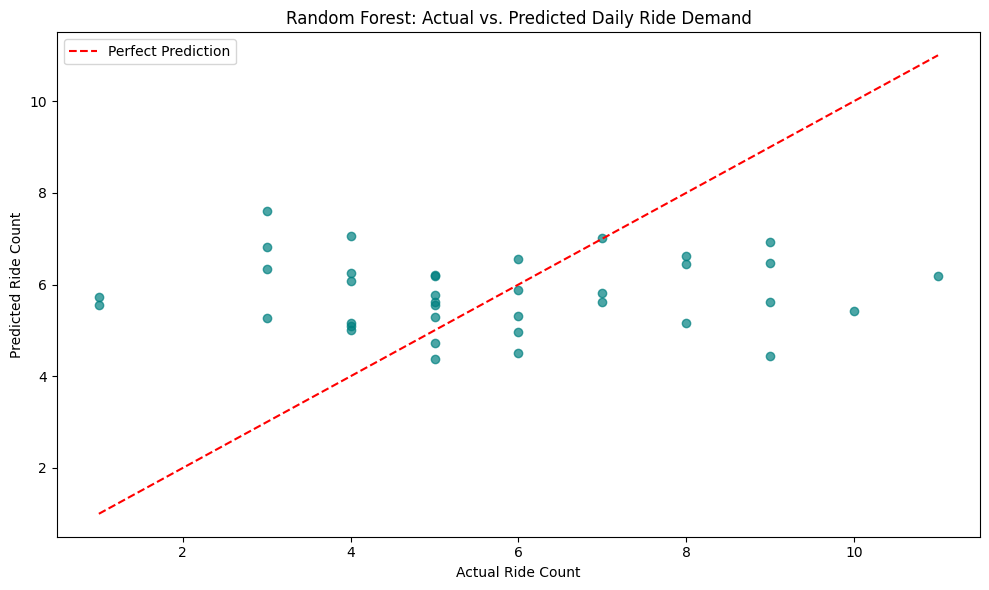

In [7]:
rf_preds = rf_model.predict(X_test)
plt.figure(figsize=(10,6))
plt.scatter(y_test, rf_preds, alpha=0.7, color='teal')
mn, mx = min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())
plt.plot([mn,mx],[mn,mx],'r--', label='Perfect Prediction')
plt.xlabel('Actual Ride Count'); plt.ylabel('Predicted Ride Count')
plt.title('Random Forest: Actual vs. Predicted Daily Ride Demand')
plt.legend(); plt.tight_layout(); plt.show()